# FMNIST: how does performativity affect backdoor vulnerability?

Centralized RGD on Fashion-MNIST + PerfFL's class-resampling performativity.

Poisoning: Fixed BadNets patch of size **δ x δ**, sweeping sampling temperature **α** as performativity strength.

**α = 0** is the non-performative comparison: just relabeling with no patch

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "fmnist":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import torch

from fmnist.experiment_setup import load_fmnist, make_model
from fmnist.algorithms import run_rgd, evaluate
from fmnist import backdoor
from fmnist.plotting import (
    plot_asr_over_rounds_grid,
    plot_class_mix_grid,
    plot_target_class_dynamics_grid,
    plot_asr_vs_alpha,
    save_figure,
)

## Hyperparameters

In [ ]:
# data / training
TRAIN_PER_CLASS = 50
TEST_PER_CLASS = 200
N_ROUNDS = 30
LR = 0.05
EPOCHS = 1          # gradient passes per RGD round
BATCH_SIZE = 128
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
SEED = 0            # seed used for data loading / model init ordering; run seeds are separate (below)

# attack (see fmnist/backdoor.py for trigger shape / target label)
POISON_RATE = 0.02   # epsilon: fraction of training set triggered

# performativity
# ALPHAS: every alpha actually run. the ASR-vs-alpha sweep plots ALL of these.
# PLOT_ALPHAS: coarse subset shown as panels in the over-rounds grids (must be a subset of ALPHAS).
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4.0]
PLOT_ALPHAS = [0.0, 0.5, 1.0, 2.0, 4.0]
EVAL_WINDOW = 5     # rounds averaged for the sweep summary

# seeds: each alpha is run once per seed (model init + poison draws vary), and
# every plot shows the mean with a shaded +/-1 std band across these seeds.
SEEDS = [0, 1, 2, 3, 4]

## Load data

In [3]:
train_x, train_y, test_x, test_y = load_fmnist(
    data_root=str(root / "data"),
    train_per_class=TRAIN_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    seed=SEED,
)
print("train:", train_x.shape, "test:", test_x.shape)

train: torch.Size([5000, 1, 28, 28]) test: torch.Size([2000, 1, 28, 28])


## Run all alphas x seeds

Run clean + poisoned RGD for every alpha in `ALPHAS`, repeated once per seed in
`SEEDS`, and store the full per-seed histories in `runs`, plus a derived
`summary_rows` (mean +/-1 std across seeds). Change `PLOT_ALPHAS`, `SEEDS`, or
swap plots and re-run just the plot cells -- **not** this runs cell, unless you
add a new alpha or seed.

In [4]:
def run_pair(alpha, seed=SEED):
    """Return (clean_history, poisoned_history) for one alpha."""
    asr_fn = backdoor.make_asr_fn(test_x, test_y, device=DEVICE)
    prior_fn = backdoor.make_prior_fn(test_x, test_y, device=DEVICE)
    common = dict(
        alpha=alpha, n_rounds=N_ROUNDS, lr=LR, epochs=EPOCHS,
        batch_size=BATCH_SIZE, device=DEVICE,
    )

    # clean run (no poison)
    clean_model = make_model(seed=seed, device=DEVICE)
    clean_hist = run_rgd(clean_model, train_x, train_y, test_x, test_y,
                         asr_fn=asr_fn, **common)

    # poisoned run: select and trigger one epsilon-fraction once, before RGD.
    # run_rgd reuses this exact poisoned tensor every round, so each poisoned
    # image stays poisoned for the full trajectory (a truly static attack).
    def poison_fn(x, y):
        return backdoor.badnets_poison(x, y, poison_rate=POISON_RATE, seed=seed + 1)

    pois_model = make_model(seed=seed, device=DEVICE)
    pois_hist = run_rgd(pois_model, train_x, train_y, test_x, test_y,
                        poison_fn=poison_fn, asr_fn=asr_fn, prior_fn=prior_fn, **common)
    return clean_hist, pois_hist

In [5]:
# The one expensive cell: len(ALPHAS) * len(SEEDS) * 2 (clean + poisoned) RGD runs.
# runs[alpha] = list of (clean_hist, pois_hist), one pair per seed.
runs = {a: [run_pair(a, seed=s) for s in SEEDS] for a in ALPHAS}

def _tail_mean(hist, key):
    return sum(h[key] for h in hist[-EVAL_WINDOW:]) / EVAL_WINDOW

def _mean_std(values):
    n = len(values)
    m = sum(values) / n
    var = sum((v - m) ** 2 for v in values) / n  # population std
    return m, var ** 0.5

# derived summary (one row per alpha): tail-mean per seed, then mean +/-1 std
# across seeds. No extra training -- just re-reading `runs`.
summary_rows = []
for a in ALPHAS:
    seed_runs = runs[a]  # list of (clean_hist, pois_hist), one per seed
    clean_tail = [_tail_mean(ch, "clean_acc") for ch, ph in seed_runs]
    pois_tail = [_tail_mean(ph, "clean_acc") for ch, ph in seed_runs]
    asr_tail = [_tail_mean(ph, "asr") for ch, ph in seed_runs]
    prior_tail = [_tail_mean(ph, "prior_rate") for ch, ph in seed_runs]

    clean_mean, clean_std = _mean_std(clean_tail)
    pois_mean, pois_std = _mean_std(pois_tail)
    asr_mean, asr_std = _mean_std(asr_tail)
    prior_mean, prior_std = _mean_std(prior_tail)

    summary_rows.append({
        "alpha": a, "n_seeds": len(SEEDS),
        "asr_mean": asr_mean, "asr_std": asr_std,
        "prior_rate_mean": prior_mean, "prior_rate_std": prior_std,
        "clean_acc_mean": clean_mean, "clean_acc_std": clean_std,
        "poisoned_acc_mean": pois_mean, "poisoned_acc_std": pois_std,
    })
    print(f"alpha={a:>4}  ASR={asr_mean:.3f}±{asr_std:.3f}  prior={prior_mean:.3f}±{prior_std:.3f}  "
          f"clean_acc={clean_mean:.3f}±{clean_std:.3f}  poisoned_acc={pois_mean:.3f}±{pois_std:.3f}")

alpha= 0.0  ASR=0.954±0.011  prior=0.023±0.003  clean_acc=0.834±0.004  poisoned_acc=0.830±0.003
alpha=0.25  ASR=0.954±0.009  prior=0.018±0.003  clean_acc=0.830±0.006  poisoned_acc=0.830±0.006
alpha= 0.5  ASR=0.948±0.018  prior=0.019±0.003  clean_acc=0.829±0.005  poisoned_acc=0.834±0.002
alpha=0.75  ASR=0.956±0.005  prior=0.019±0.002  clean_acc=0.828±0.004  poisoned_acc=0.831±0.004
alpha= 1.0  ASR=0.955±0.007  prior=0.019±0.003  clean_acc=0.826±0.006  poisoned_acc=0.830±0.003
alpha=1.25  ASR=0.951±0.017  prior=0.019±0.003  clean_acc=0.820±0.006  poisoned_acc=0.822±0.005
alpha= 1.5  ASR=0.960±0.015  prior=0.018±0.002  clean_acc=0.820±0.004  poisoned_acc=0.821±0.010
alpha=1.75  ASR=0.950±0.019  prior=0.018±0.004  clean_acc=0.814±0.007  poisoned_acc=0.811±0.008
alpha= 2.0  ASR=0.872±0.068  prior=0.014±0.002  clean_acc=0.767±0.041  poisoned_acc=0.735±0.029
alpha= 2.5  ASR=0.658±0.135  prior=0.036±0.013  clean_acc=0.682±0.018  poisoned_acc=0.677±0.013
alpha= 3.0  ASR=0.471±0.149  prior=0.063

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_over_rounds_grid_eps0.02_20260722_124519.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_over_rounds_grid_eps0.02_20260722_124519.png')

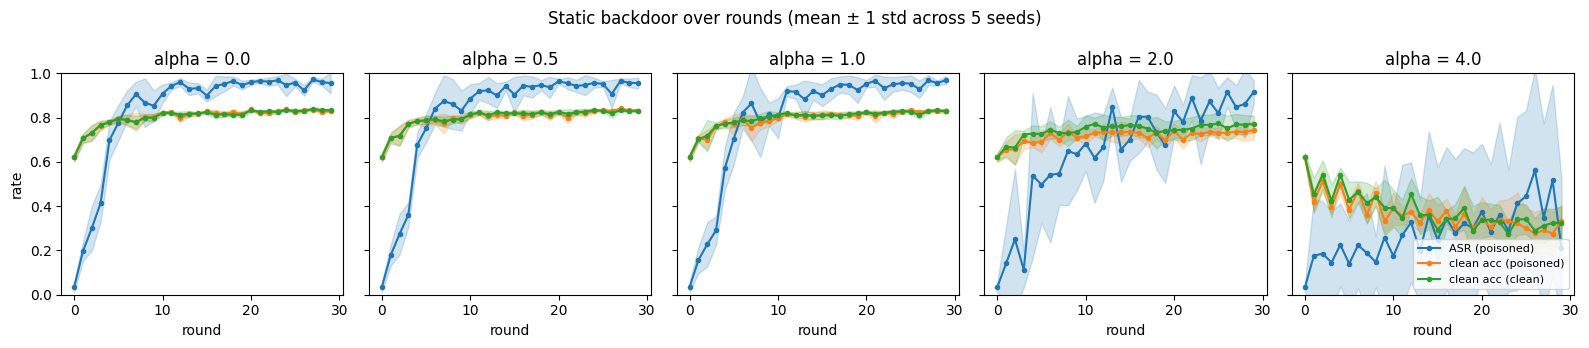

In [6]:
# Backdoor over rounds -- one panel per alpha in PLOT_ALPHAS, mean +/-1 std
# across SEEDS (shaded band). Plots from `runs`.
fig = plot_asr_over_rounds_grid({a: runs[a] for a in PLOT_ALPHAS})
save_figure(fig, f"asr_over_rounds_grid_eps{POISON_RATE}")

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/class_mix_grid_eps0.02_20260722_124519.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/class_mix_grid_eps0.02_20260722_124519.png')

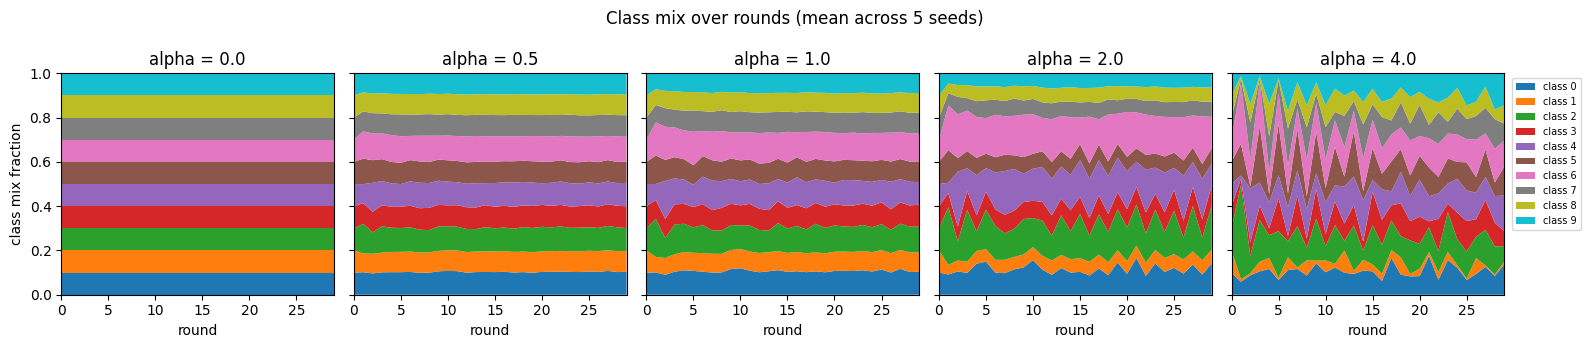

In [7]:
# Class mix over rounds -- one stacked-area panel per alpha in PLOT_ALPHAS,
# averaged over SEEDS (clean run's class_mix; composition plots aren't shaded).
# To see the poisoned run's mix instead, edit plot_class_mix_grid in
# fmnist/plotting.py to read pair[1] instead of pair[0].
fig = plot_class_mix_grid({a: runs[a] for a in PLOT_ALPHAS})
save_figure(fig, f"class_mix_grid_eps{POISON_RATE}")

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/target_class_feedback_eps0.02_20260722_124519.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/target_class_feedback_eps0.02_20260722_124519.png')

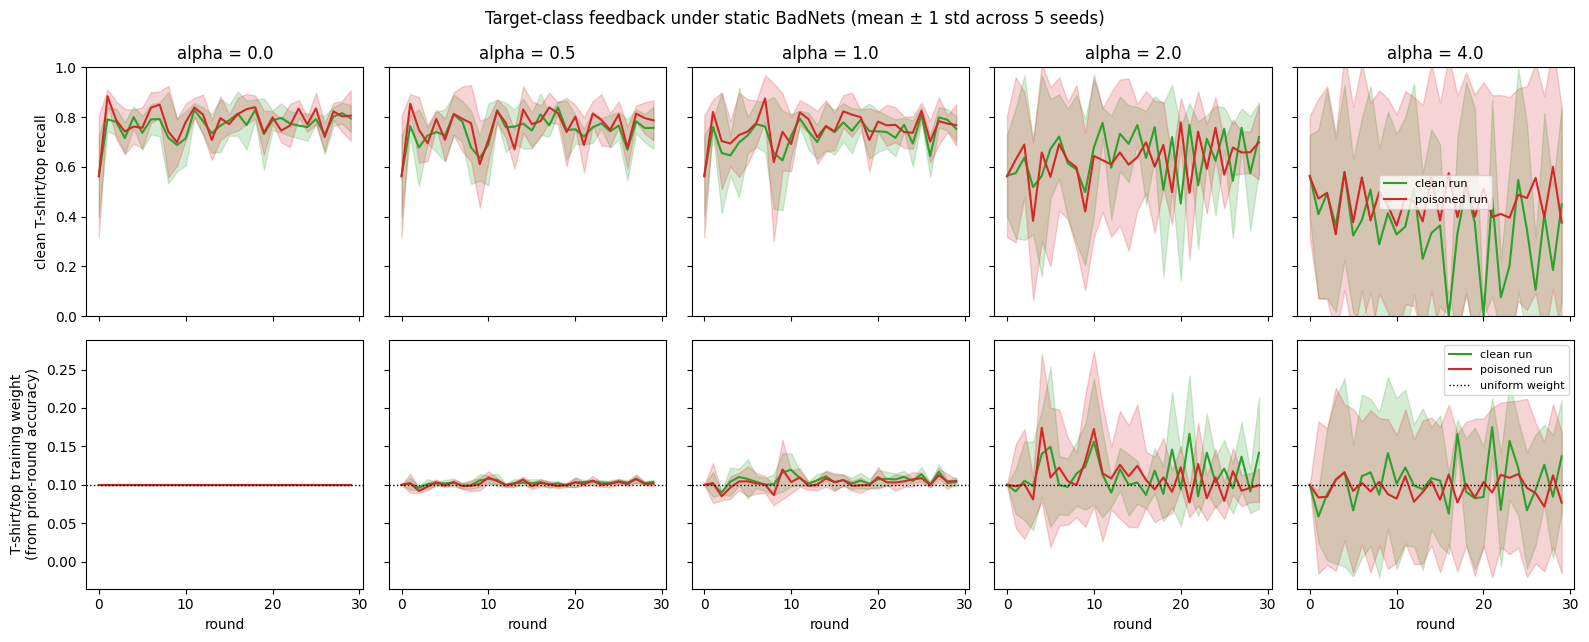

In [8]:
# Clean vs poisoned target-class accuracy and its training weight.
fig = plot_target_class_dynamics_grid(
    {a: runs[a] for a in PLOT_ALPHAS},
    target_label=backdoor.TARGET_LABEL,
    target_name="T-shirt/top",
)
save_figure(fig, f"target_class_feedback_eps{POISON_RATE}")

## Sweep: ASR & accuracy vs alpha

The full sweep over every alpha in `ALPHAS`, mean +/-1 std across `SEEDS`,
from `summary_rows`.

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_vs_alpha_eps0.02_20260722_124520.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/asr_vs_alpha_eps0.02_20260722_124520.png')

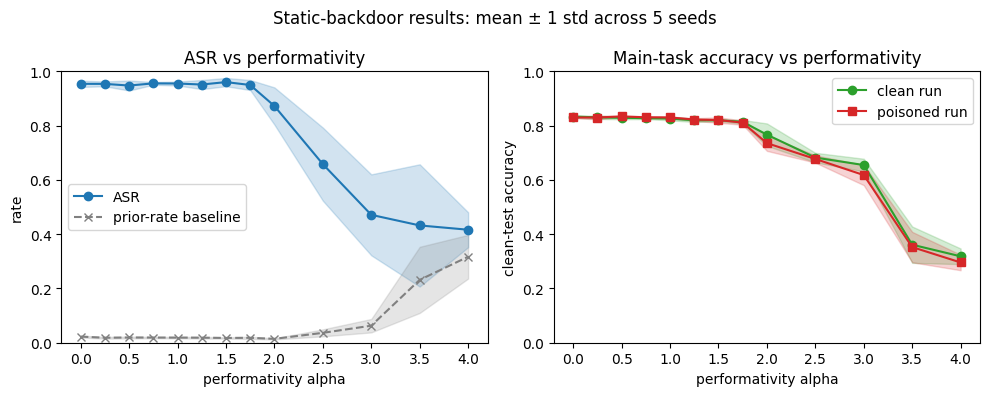

In [9]:
fig = plot_asr_vs_alpha(summary_rows)
save_figure(fig, f"asr_vs_alpha_eps{POISON_RATE}")